In [1]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
df = pd.read_csv('asthma_prediction_dataset_v3.csv')

In [3]:
df.head()

,Age,Gender,BMI,Smoking,Family_History,Allergy,Air_Pollution_Index,Exercise_Induced_Symptoms,Respiratory_Rate,Cough_Frequency,Dust_Exposure_Level,Oxygen_Saturation,Asthma
0,56,Female,24.4,No,No,No,155,Yes,21,4,8,98.1,0
1,19,Female,24.1,No,No,No,239,No,23,2,2,96.4,0
2,76,Male,26.4,Yes,No,No,196,No,27,0,1,94.3,0
3,65,Male,31.8,No,No,Yes,195,No,17,3,3,96.1,0
4,25,Female,29.6,Yes,Yes,Yes,137,Yes,22,2,1,99.8,1


In [4]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Smoking', 'Family_History', 'Allergy',
       'Air_Pollution_Index', 'Exercise_Induced_Symptoms', 'Respiratory_Rate',
       'Cough_Frequency', 'Dust_Exposure_Level', 'Oxygen_Saturation',
       'Asthma'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1500 non-null   int64  
 1   Gender                     1500 non-null   object 
 2   BMI                        1500 non-null   float64
 3   Smoking                    1500 non-null   object 
 4   Family_History             1500 non-null   object 
 5   Allergy                    1500 non-null   object 
 6   Air_Pollution_Index        1500 non-null   int64  
 7   Exercise_Induced_Symptoms  1500 non-null   object 
 8   Respiratory_Rate           1500 non-null   int64  
 9   Cough_Frequency            1500 non-null   int64  
 10  Dust_Exposure_Level        1500 non-null   int64  
 11  Oxygen_Saturation          1500 non-null   float64
 12  Asthma                     1500 non-null   int64  
dtypes: float64(2), int64(6), object(5)
memory usage:

In [6]:
print(df.isnull().sum())

Age                          0
Gender                       0
BMI                          0
Smoking                      0
Family_History               0
Allergy                      0
Air_Pollution_Index          0
Exercise_Induced_Symptoms    0
Respiratory_Rate             0
Cough_Frequency              0
Dust_Exposure_Level          0
Oxygen_Saturation            0
Asthma                       0
dtype: int64


In [7]:
df.describe()

,Age,BMI,Air_Pollution_Index,Respiratory_Rate,Cough_Frequency,Dust_Exposure_Level,Oxygen_Saturation,Asthma
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,41.459333,25.163200,178.763333,19.565333,2.939333,4.528667,96.930067,0.392000
std,21.738308,3.947038,60.004486,4.056357,1.726743,2.792319,1.943796,0.488359
min,5.000000,11.500000,20.000000,8.000000,0.000000,0.000000,90.000000,0.000000
25%,22.000000,22.500000,138.000000,17.000000,2.000000,2.000000,95.600000,0.000000
50%,41.000000,25.200000,180.000000,20.000000,3.000000,5.000000,96.900000,0.000000
75%,61.000000,27.900000,219.000000,22.000000,4.000000,7.000000,98.300000,1.000000
max,79.000000,39.000000,384.000000,32.000000,12.000000,9.000000,103.600000,1.000000


In [8]:
numerical_column_names = df.select_dtypes(include=['number']).columns.tolist()
print(numerical_column_names)

['Age', 'BMI', 'Air_Pollution_Index', 'Respiratory_Rate', 'Cough_Frequency', 'Dust_Exposure_Level', 'Oxygen_Saturation', 'Asthma']


In [9]:
object_column_names = df.select_dtypes(include=['object']).columns.tolist()
print(object_column_names)

['Gender', 'Smoking', 'Family_History', 'Allergy', 'Exercise_Induced_Symptoms']


In [10]:
df = pd.read_csv('asthma_prediction_dataset_v3.csv')

df_shuffled = shuffle(df, random_state=42)  

df_shuffled = df_shuffled.reset_index(drop=True)

print(df_shuffled['Asthma'].value_counts())  


Asthma
0    912
1    588
Name: count, dtype: int64


In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown').astype(str)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Categorical columns successfully encoded!")

Categorical columns successfully encoded!


In [12]:

X = df.drop('Asthma', axis=1).values
y = df['Asthma'].astype(int).values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

print("Before SMOTE:", np.bincount(y))
print("After SMOTE:", np.bincount(y_res))


X_seq = X_res.reshape((X_res.shape[0], X_res.shape[1], 1))


X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_res, test_size=0.2, random_state=42
)

Before SMOTE: [912 588]
After SMOTE: [912 912]


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Bidirectional, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(GaussianNoise(0.01, input_shape=(X_seq.shape[1], 1)))

model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.2))

model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.2))

model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())

model.add(Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)))
model.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


C:\Users\AB TECHNOLOGIES\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\regularization\gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)       │ (None, 12, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 12, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 6, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 6, 128)              │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 6, 128)              │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 3, 128)              │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 3, 128)              │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 3, 256)              │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 544,897 (2.08 MB)

 Trainable params: 544,001 (2.08 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.6701 - loss: 0.6189 - val_accuracy: 0.7397 - val_loss: 0.6876 - learning_rate: 0.0010
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7644 - loss: 0.5074 - val_accuracy: 0.7192 - val_loss: 0.6688 - learning_rate: 0.0010
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8166 - loss: 0.4215 - val_accuracy: 0.7329 - val_loss: 0.6409 - learning_rate: 0.0010
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8329 - loss: 0.3889 - val_accuracy: 0.8116 - val_loss: 0.5942 - learning_rate: 0.0010
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8535 - loss: 0.3635 - val_accuracy: 0.8185 - val_loss: 0.5619 - learning_rate: 0.0010
Epoch 6/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8620 - loss: 0.3278 - val_accuracy: 0.7808 - val_loss: 0.5110 - learning_rate: 0.0010
Epoch 7/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8783 - loss: 0.3178 -

In [14]:

model.save("model.h5")
print("Model saved as model.h5")


Model saved as model.h5


In [15]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as scaler.pkl")

Scaler saved as scaler.pkl


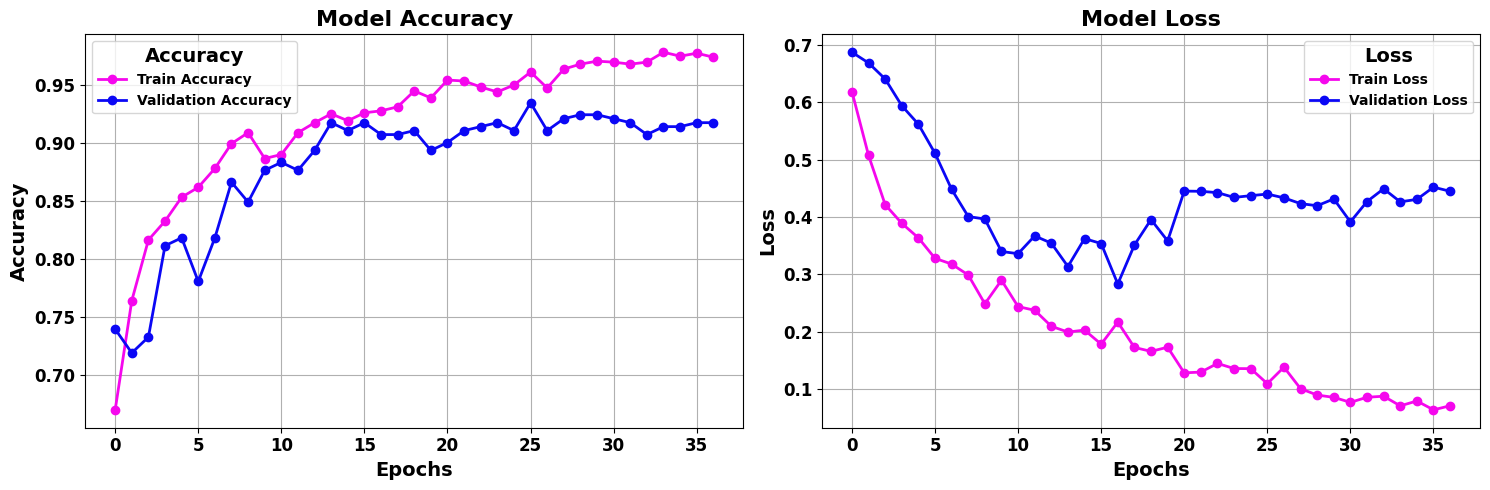

In [16]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', linewidth=2, color='#f507ed')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', linewidth=2, color='#0b07f5')
plt.title('Model Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(title='Accuracy', title_fontsize=14, fontsize=12, prop={'weight':'bold'})
plt.setp(plt.gca().get_legend().get_title(), fontweight='bold')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', linewidth=2, color='#f507ed')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', linewidth=2, color='#0b07f5')
plt.title('Model Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(title='Loss', title_fontsize=14, fontsize=12, prop={'weight':'bold'})
plt.setp(plt.gca().get_legend().get_title(), fontweight='bold')
plt.grid(True)

plt.tight_layout()
plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step


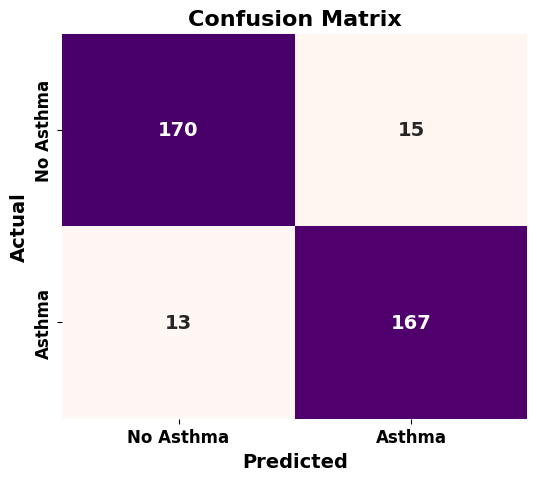

CLASSIFICATION REPORT:

              PRECISION    RECALL  F1-SCORE   SUPPORT

   NO ASTHMA       0.93      0.92      0.92       185
      ASTHMA       0.92      0.93      0.92       180

    ACCURACY                           0.92       365
   MACRO AVG       0.92      0.92      0.92       365
WEIGHTED AVG       0.92      0.92      0.92       365



In [17]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
class_names = ["No Asthma", "Asthma"]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='RdPu', cbar=False,   
    annot_kws={"size":14, "weight":"bold"},
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted", fontsize=14, fontweight='bold')
plt.ylabel("Actual", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.show()

BOLD = '\033[1m'
END = '\033[0m'

print(f"{BOLD}CLASSIFICATION REPORT:{END}\n")
report = classification_report(
    y_test, y_pred, target_names=class_names
)
print(f"{BOLD}{report.upper()}{END}")



In [18]:
import numpy as np

patient_data_batch = np.array([
    [56,0,24.4,0,0,0,155,1,21,4,8,98.1],  # 56F
    [19,0,24.1,0,0,0,239,0,23,2,2,96.4],  # 19F
    [76,1,26.4,1,0,0,196,0,27,0,1,94.3],  # 76M
    [65,1,31.8,0,0,1,195,0,17,3,3,96.1],  # 65M
    [25,0,29.6,1,1,1,137,1,22,2,1,99.8],  # 25F
    [79,0,23.5,0,0,0,172,0,21,6,6,97.4],  # 79F
    [79,1,27.2,1,1,1,180,0,20,1,9,97.0],  # 79M
    [28,1,30.0,0,1,0,174,1,22,2,5,96.2],  # 28M
    [7,1,26.6,0,1,1,224,0,18,2,7,96.4],   # 7M
    
], dtype=np.float32)

patient_data_scaled = scaler.transform(patient_data_batch)


patient_data_scaled = patient_data_scaled.reshape(
    patient_data_scaled.shape[0],
    patient_data_scaled.shape[1],
    1
)


pred_probs = model.predict(patient_data_scaled)


pred_classes = [int(round(p[0])) for p in pred_probs]
label_map = {0: "No Asthma", 1: "Asthma"}


for i, p in enumerate(pred_classes):
    print(f"Patient {i+1}: {label_map[p]} (Probability: {round(pred_probs[i][0],2)})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Patient 1: No Asthma (Probability: 0.1599999964237213)
Patient 2: No Asthma (Probability: 0.10000000149011612)
Patient 3: No Asthma (Probability: 0.3700000047683716)
Patient 4: No Asthma (Probability: 0.05000000074505806)
Patient 5: Asthma (Probability: 1.0)
Patient 6: No Asthma (Probability: 0.3700000047683716)
Patient 7: Asthma (Probability: 1.0)
Patient 8: No Asthma (Probability: 0.0)
Patient 9: Asthma (Probability: 0.8500000238418579)
